In [35]:
# ================================
# 1. IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

#from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




In [36]:
# ================================
# 2. LOAD DATA
# ================================
data = pd.read_csv('data.csv')
data.drop(["Unnamed: 32", "id"], axis=1,inplace=True)




In [37]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [38]:
data.shape

(569, 31)

# EDA (Exploratory Data Analysis)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [40]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [41]:
data.groupby('diagnosis')['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

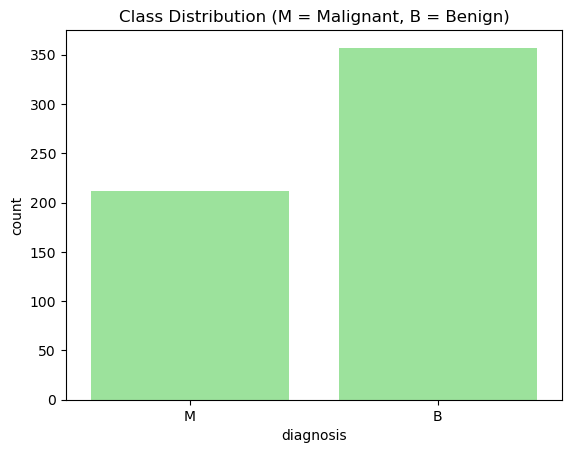

In [42]:
# ================================
# 3. EDA
# ================================
sns.countplot(x='diagnosis',data=data,color='lightgreen')
plt.title("Class Distribution (M = Malignant, B = Benign)")
plt.show()

data["diagnosis"] = data["diagnosis"].map({"B":0,"M":1})





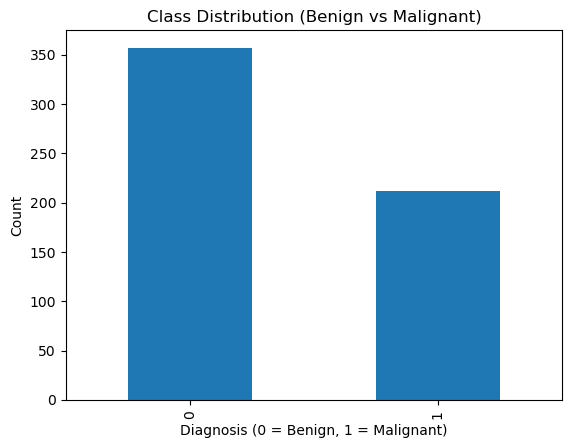

In [43]:

data['diagnosis'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Benign vs Malignant)")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()

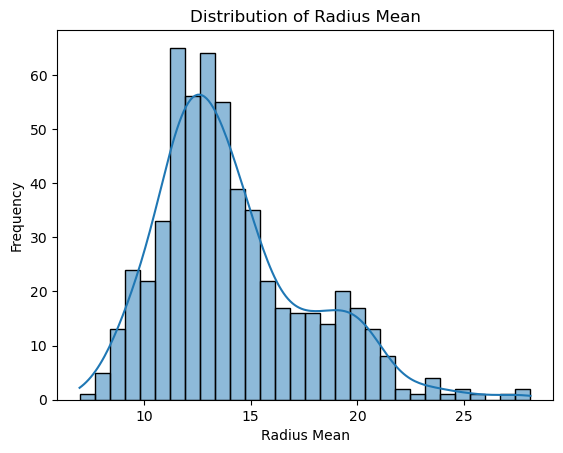

In [44]:
sns.histplot(data['radius_mean'], bins=30,kde=True)
plt.title("Distribution of Radius Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.show()

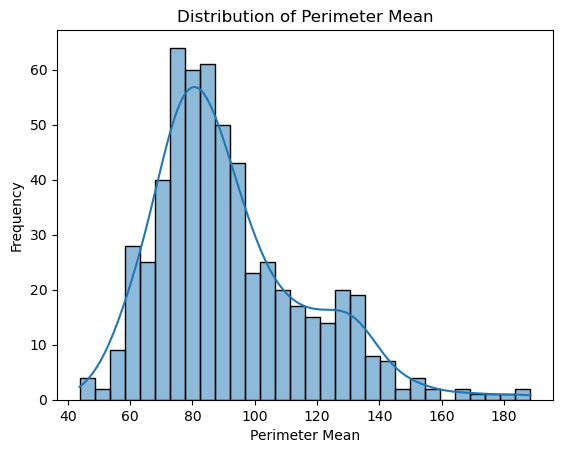

In [45]:
sns.histplot(data['perimeter_mean'], bins=30,kde=True)
plt.title("Distribution of Perimeter Mean")
plt.xlabel("Perimeter Mean")
plt.ylabel("Frequency")
plt.show()

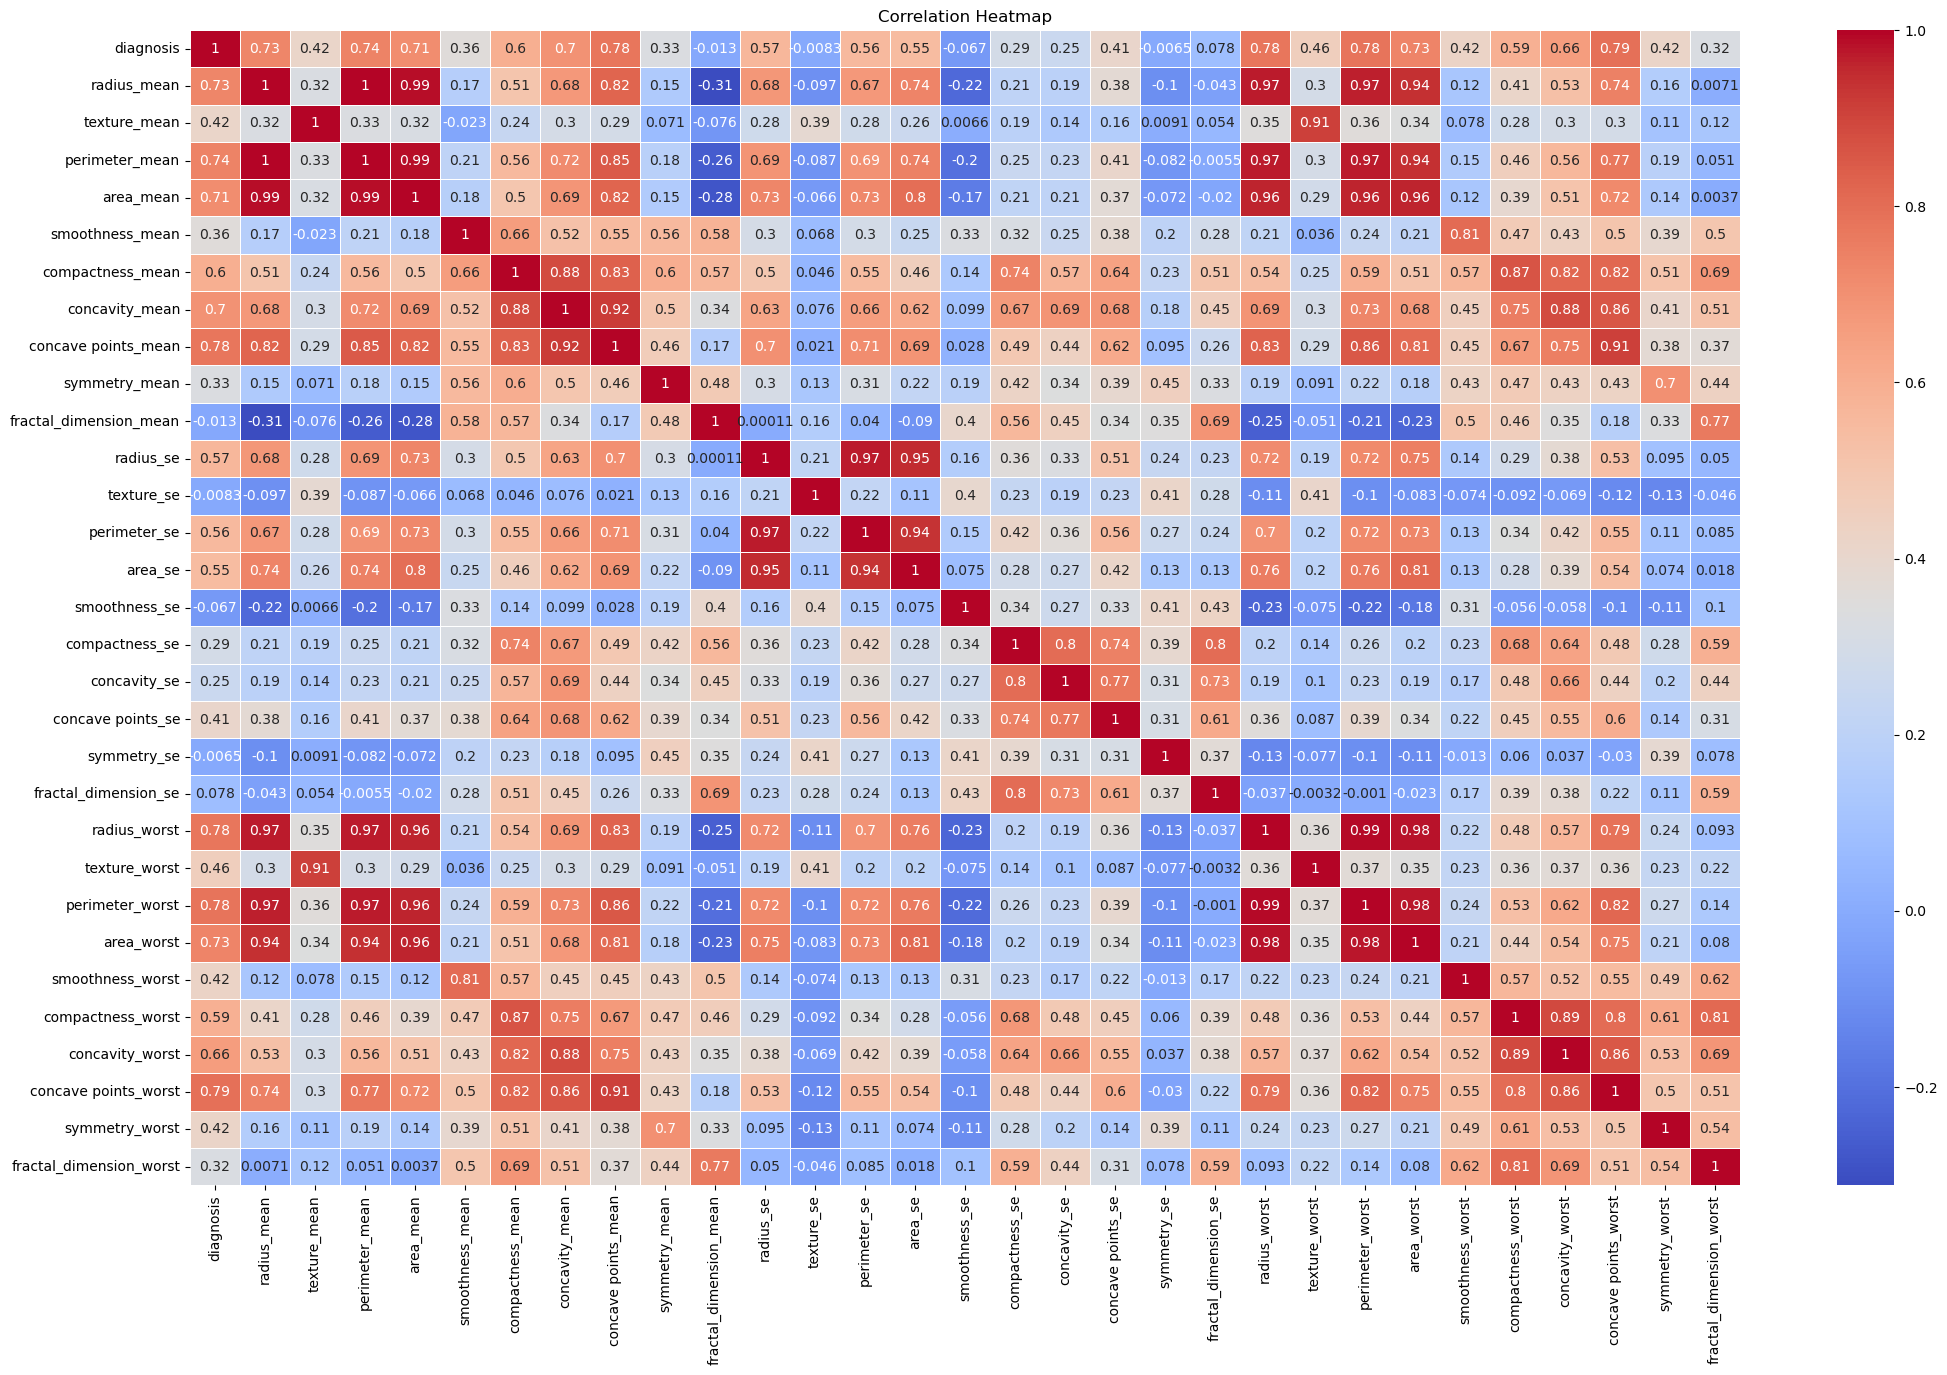

In [46]:
plt.figure(figsize=(25, 15))
sns.heatmap(data.corr(), cmap="coolwarm",annot=True,linewidth=.5)
plt.title("Correlation Heatmap")
plt.show()


In [47]:
# ================================
# 4. SPLIT DATA
# ================================
X = data.drop(["diagnosis"], axis=1)
y = data["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




In [48]:
# ================================
# 5. FEATURE SELECTION (TOP 5)
# ================================
selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("\nTop 5 Selected Features:")
print(selected_features)





Top 5 Selected Features:
Index(['perimeter_mean', 'concave points_mean', 'radius_worst',
       'perimeter_worst', 'concave points_worst'],
      dtype='object')


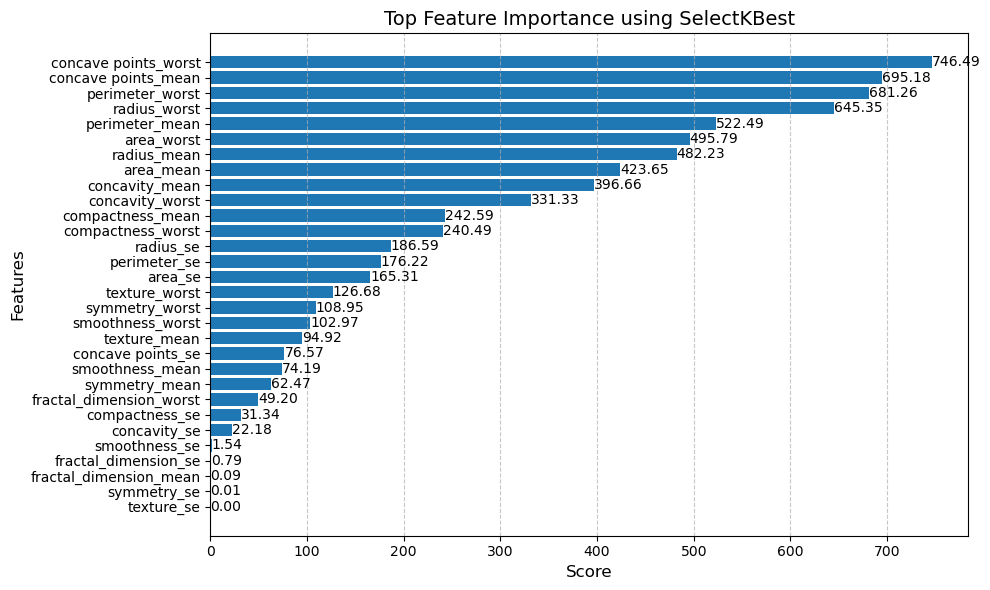

In [49]:

# Create DataFrame for better handling
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

# Sort values for better visualization
feature_scores = feature_scores.sort_values(by='Score', ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_scores['Feature'], feature_scores['Score'])

plt.title("Top Feature Importance using SelectKBest", fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add score labels on bars
for index, value in enumerate(feature_scores['Score']):
    plt.text(value, index, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()

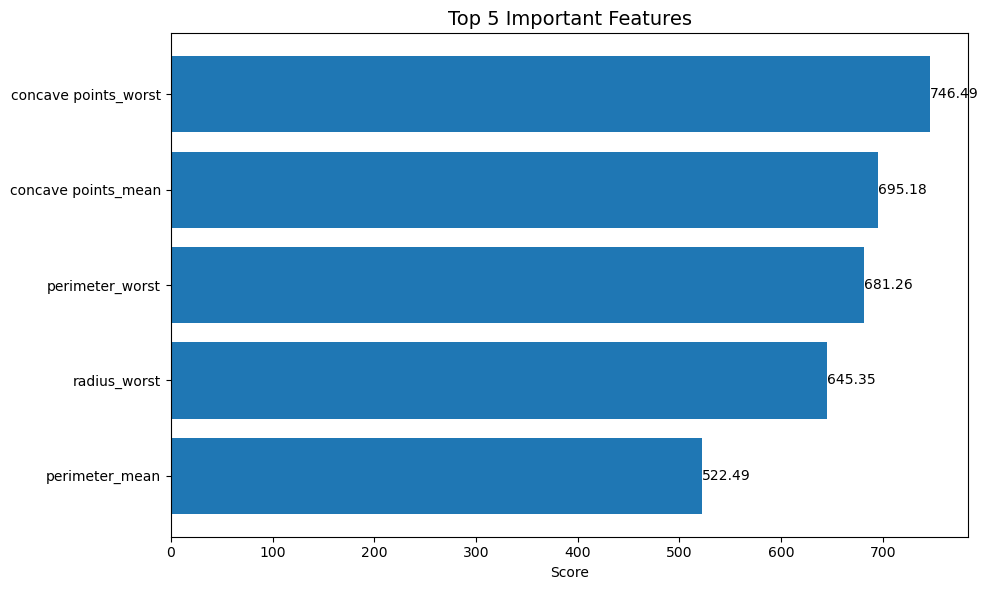

In [50]:
top_features = feature_scores.tail(5)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Score'])

plt.title("Top 5 Important Features", fontsize=14)
plt.xlabel("Score")

for index, value in enumerate(top_features['Score']):
    plt.text(value, index, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()

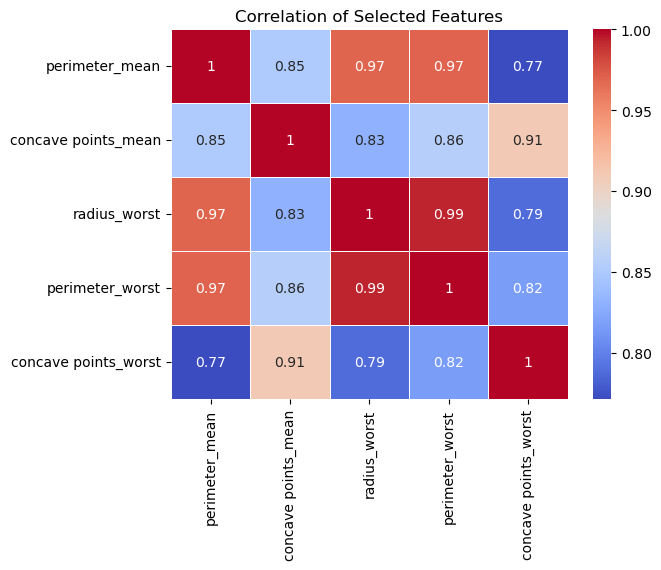

In [51]:
#heat map of corelation of top 5 selected feaures
sns.heatmap(data[selected_features].corr() ,cmap="coolwarm",annot=True,linewidth=.5)
plt.title("Correlation of Selected Features")
plt.show()


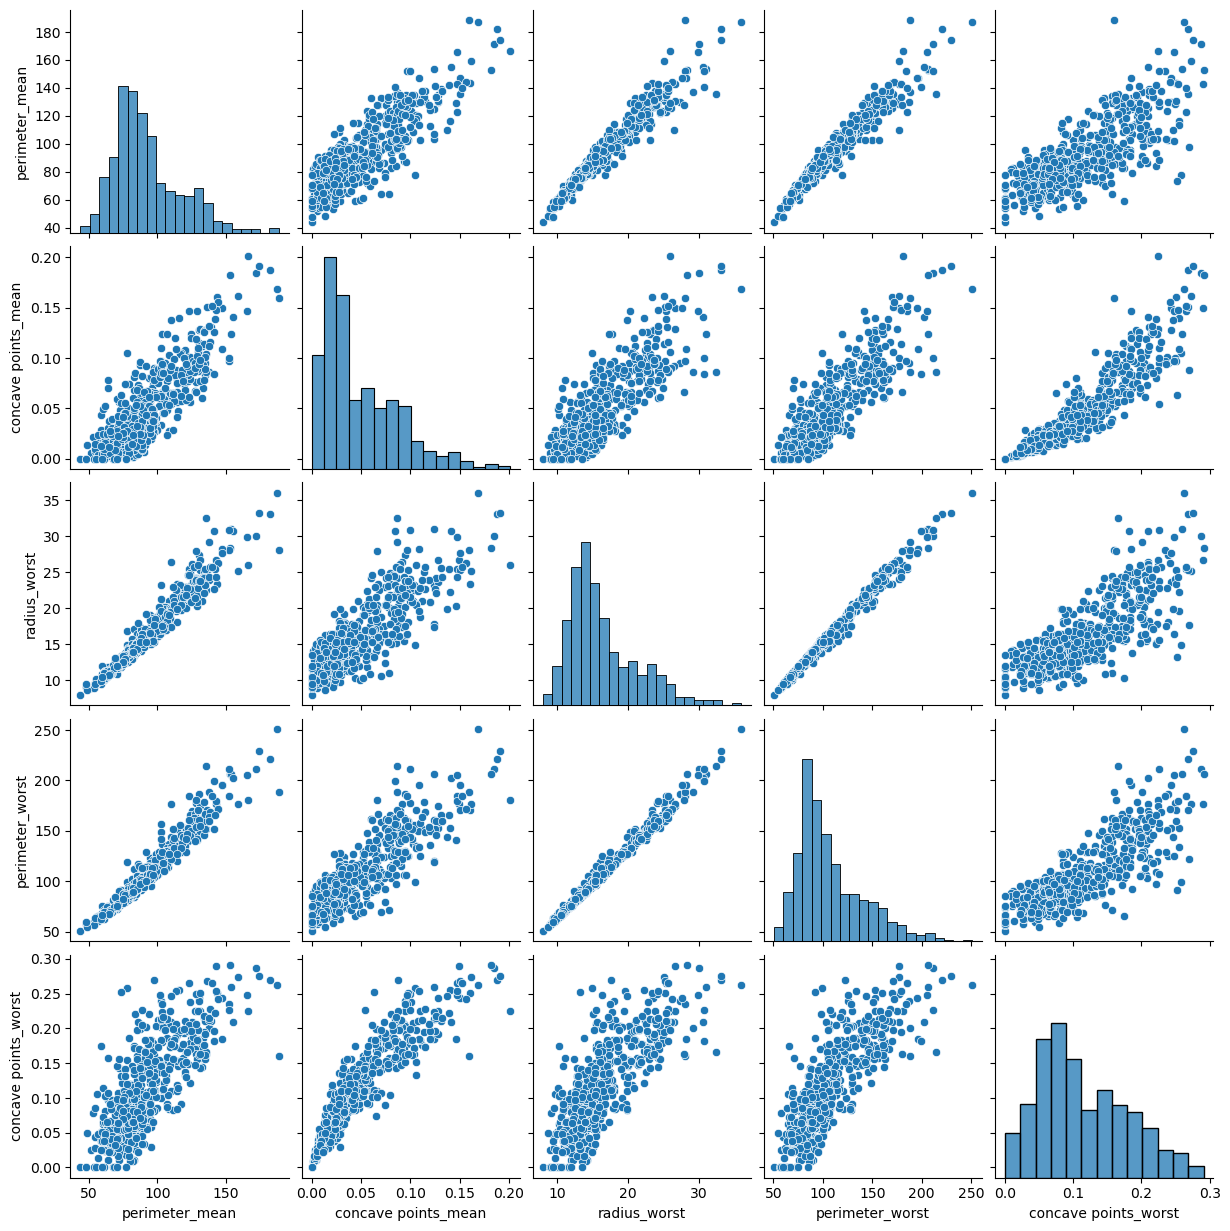

In [52]:
sns.pairplot(data[selected_features])

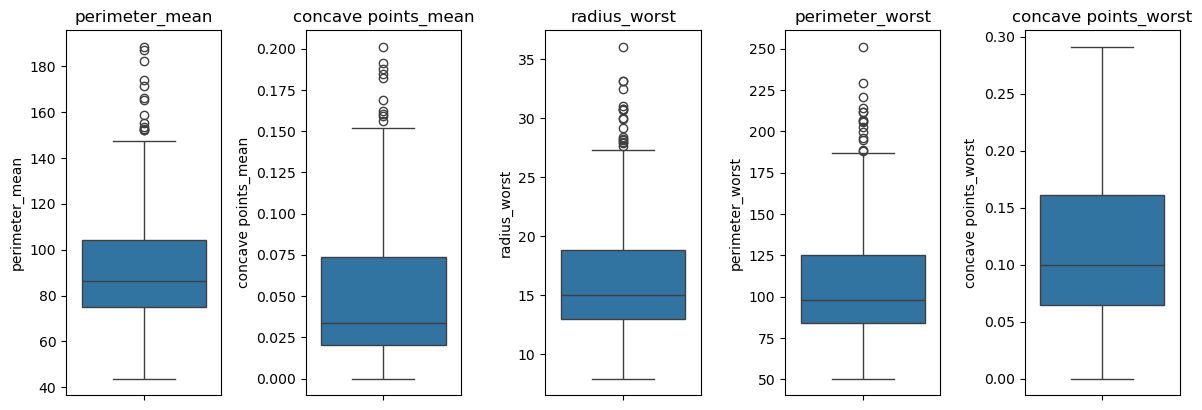

In [53]:
# 1. Set the overall figure size
plt.figure(figsize=(12, 8))

# 2. Correct the counter initialization (from 'in=1' to 'i=1')
i = 1 

# 3. Iterate through your list of features
for column in selected_features:
    # Create a subplot in a 1-row, 5-column grid
    plt.subplot(2, 5, i)
    
    # Plot the boxplot (ensure 'column' matches the loop variable)
    sns.boxplot(y=data[column]) 
    
    plt.title(column) # Optional: adds a title to each subplot
    i += 1

# 4. Adjust spacing between plots
plt.tight_layout()
plt.show()

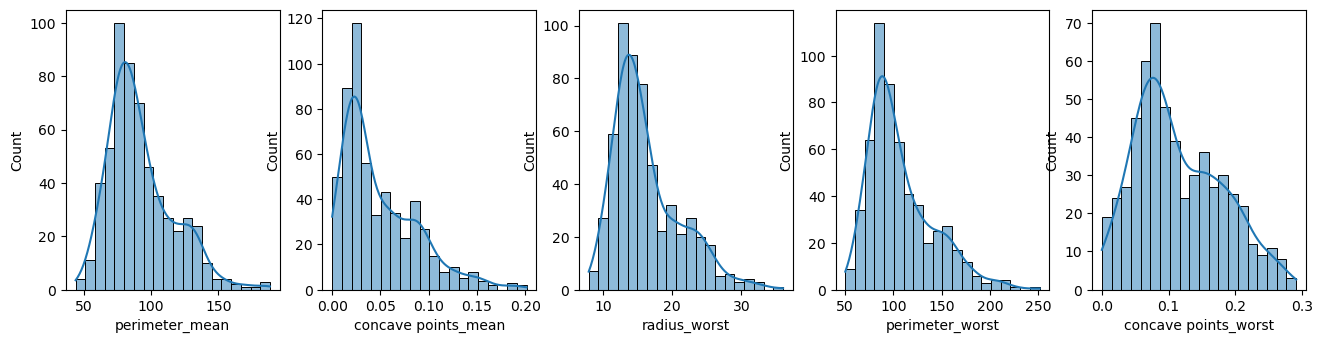

In [54]:
# 1. Set the overall figure size
plt.figure(figsize=(16, 8))

# 2. Correct the counter initialization (from 'in=1' to 'i=1')
i = 1 

for col in selected_features:
    plt.subplot(2, 5, i)
    sns.histplot(data[col],bins=20,kde=True)

    i += 1

In [55]:
# ================================
# 6. SCALING (AFTER SELECTION)
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)




In [56]:
# ================================
# 7. MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier()
}

results = {}




In [57]:
# ================================
# 8. TRAIN & EVALUATE
# ================================
models_=[]

for name, model in models.items():
    models_.append(model.fit(X_train_scaled, y_train))
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    results[name] = {
        "model": model,
        "accuracy": acc,
        "y_pred": y_pred
    }





Logistic Regression
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Decision Tree
Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114


SVC
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
 

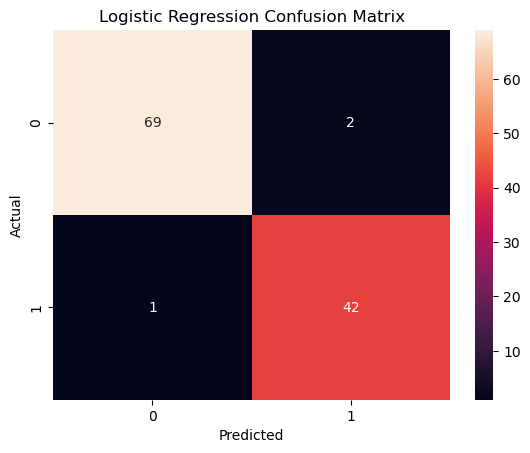

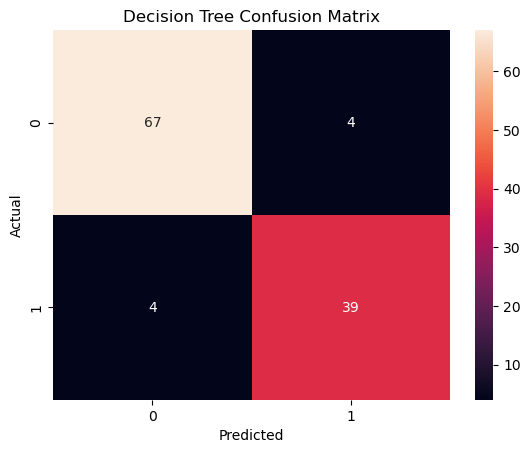

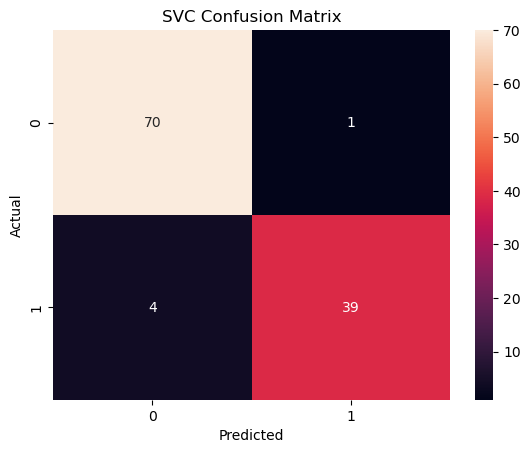

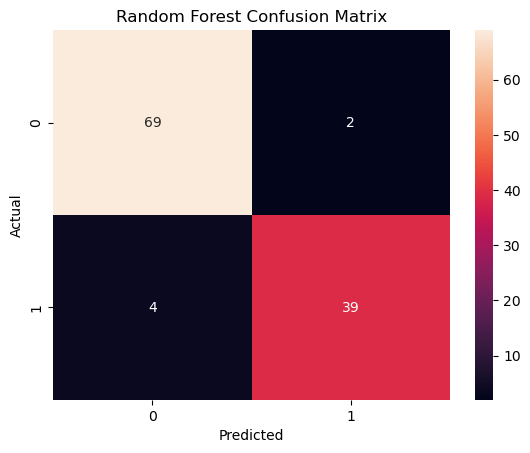

In [58]:
# ================================
# 9. CONFUSION MATRICES
# ================================
for name in results:
    cm = confusion_matrix(y_test, results[name]["y_pred"])

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




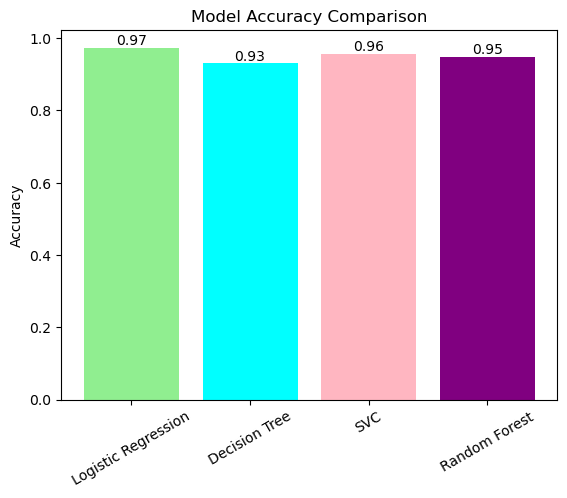

In [59]:
# ================================
# 10. MODEL COMPARISON GRAPH
# ================================
names = list(results.keys())
accuracies = [results[n]["accuracy"] for n in names]

fig, ax = plt.subplots()

bars = ax.bar(names, accuracies, color=['lightgreen','cyan','lightpink','purple'])

ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=30)

# 🔥 Add labels on bars
ax.bar_label(bars, fmt='%.2f')

plt.show()

In [60]:
# ================================
# 11. BEST MODEL
# ================================
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
best_model = results[best_model_name]["model"]

print("\nBest Model:", best_model_name)




Best Model: Logistic Regression


In [61]:
# ================================
# 12. SAVE FILES
# ================================
os.makedirs("model", exist_ok=True)

pickle.dump(best_model, open("model/model.pkl", "wb"))
pickle.dump(selector, open("model/selected_features.pkl", "wb"))
pickle.dump(scaler, open("model/scaler.pkl", "wb"))

print("\nSaved: model.pkl, selected_features.pkl, scaler.pkl")


Saved: model.pkl, selected_features.pkl, scaler.pkl


In [64]:
model=models_[0]

In [66]:
selected_features = [
    'perimeter_mean',
    'concave points_mean',
    'radius_worst',
    'perimeter_worst',
    'concave points_worst'
]

In [ ]:

plt.show()

c:\Users\pc\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: X has 30 features, but StandardScaler is expecting 5 features as input.